<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/uniprotkb_nlinked_sites.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download and Analyze Glycobiology Data from GlyGen

## Annotated N-linked Glycosylation Sites in UniProtKB with PubMed IDs

This notebook demonstrates how to download and analyze data from [data.glygen.org](https://data.glygen.org), which provides the datasets used to build GlyGen. We will use datasets from UniProtKB that provide protein site annotations (including N-linked glycosylation) with their cross-references to PubMed IDs.

## 1. Import the GlyGenDownloader class

In [1]:
#
# Import the modules from the github repository
#
import httpimport

with httpimport.github_repo("edwardsnj", "glygen-colab-notebooks", ref="main"):
  from glygen import GlyGenDownloader


## 2. Get the reviewed datasets' filenames

The GlyGen datasets at [data.glygen.org](https://data.glygen.org) have structured filenames, making it straightfoward to automatically download relevant datasets using filename wildcards. The dataframe method of the GlyGenDownloader class will form a pandas data-frame from the downloaded CSV file(s).

In [2]:
# Download UniProtKB protein site annotations for each species
ggdl = GlyGenDownloader()

template = "*_protein_site_annotation_uniprotkb.csv"
FILES = ggdl.filenames(template)

params = {
  "name": "uniprotkb_site_annotations",
  "usecols": ["uniprotkb_canonical_ac","start_pos","ref_aa","annotation","xref_key","xref_id"],
  "notna": ["start_pos","xref_id","ref_aa"],
  "asint": ["start_pos"],
  "addspecies": True,
  "dropdups": True,
}
uniprotkb_site_annotations = ggdl.dataframe(FILES,**params)


Download arabidopsis_protein_site_annotation_uniprotkb.csv... done (5.93 MB).
Download bovine_protein_site_annotation_uniprotkb.csv... done (3.91 MB).
Download chicken_protein_site_annotation_uniprotkb.csv... done (1.40 MB).
Download dicty_protein_site_annotation_uniprotkb.csv... done (672.98 KB).
Download fruitfly_protein_site_annotation_uniprotkb.csv... done (3.04 MB).
Download hamster_protein_site_annotation_uniprotkb.csv... done (752.29 KB).
Download hcv1a_protein_site_annotation_uniprotkb.csv... done (31.71 KB).
Download hcv1b_protein_site_annotation_uniprotkb.csv... done (31.34 KB).
Download human_protein_site_annotation_uniprotkb.csv... done (53.79 MB).
Download mouse_protein_site_annotation_uniprotkb.csv... done (15.80 MB).
Download pig_protein_site_annotation_uniprotkb.csv... done (1.70 MB).
Download rat_protein_site_annotation_uniprotkb.csv... done (7.69 MB).
Download sarscov1_protein_site_annotation_uniprotkb.csv... done (68.27 KB).
Download sarscov2_protein_site_annotation_

## 3. Restrict to rows of interest
From the UniProtKB site annotations, we are only interested in a specific type of glycosylation: 'N-linked (GlcNAc...) asparagine' sites. We retain only those with associated PubMed Ids.

In [3]:
# Select N-linked GlcNAc Asn sites with PubMed ids

# Select the desired degree of specificity
# nlinked_rows = uniprotkb_site_annotations["annotation"].str.contains("N-linked")
nlinked_rows = uniprotkb_site_annotations["annotation"] == "N-linked (GlcNAc...) asparagine"

pubmed_rows = uniprotkb_site_annotations["xref_key"]=="protein_xref_pubmed"

# Likely not needed
asn_rows = uniprotkb_site_annotations['ref_aa']=="N"

nlinked_sites_pubmed = uniprotkb_site_annotations[nlinked_rows&pubmed_rows&asn_rows]
nlinked_sites_pubmed = nlinked_sites_pubmed.rename(columns={"xref_id": "pubmed_id"})
nlinked_sites_pubmed = nlinked_sites_pubmed.drop(columns=["xref_key"])
nlinked_sites_pubmed

,uniprotkb_canonical_ac,start_pos,annotation,ref_aa,pubmed_id,species
1912,O64743-1,431,N-linked (GlcNAc...) asparagine,N,26037923,arabidopsis
1915,O64743-1,57,N-linked (GlcNAc...) asparagine,N,26037923,arabidopsis
2813,P24806-1,106,N-linked (GlcNAc...) asparagine,N,10406121,arabidopsis
4868,Q9FL28-1,94,N-linked (GlcNAc...) asparagine,N,24114786,arabidopsis
4870,Q9FL28-1,388,N-linked (GlcNAc...) asparagine,N,24114786,arabidopsis
...,...,...,...,...,...,...
626724,F8W463-1,113,N-linked (GlcNAc...) asparagine,N,22535247,zebrafish
626725,F8W463-1,113,N-linked (GlcNAc...) asparagine,N,19641588,zebrafish
626727,F8W463-1,187,N-linked (GlcNAc...) asparagine,N,19641588,zebrafish
626729,F8W463-1,213,N-linked (GlcNAc...) asparagine,N,19641588,zebrafish


## 4. Plot frequency of sites per PubMed ID
This section prepares and displays a histogram to visualize the distribution of the number of N-linked glycosylation sites per PubMed ID. Manuscripts with less than 10 N-liked glycosylation site annotations are excluded before plotting. Glycosylation site frequency is grouped by species.


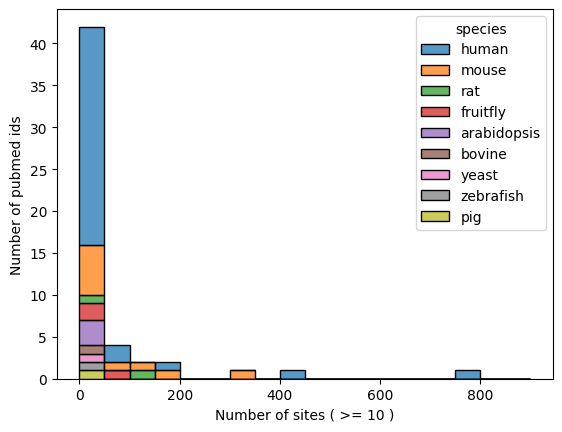

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram of frequency of sites in a pubmed id (partition by species)
counts = pd.DataFrame(nlinked_sites_pubmed[["pubmed_id","species"]].value_counts())
counts.reset_index("species", inplace=True)
counts = counts[counts["count"] >= 10]

sns.histplot(data=counts, x='count', hue="species",
             binwidth=50, binrange=(0,900), multiple="stack")
plt.xlabel("Number of sites ( >= 10 )")
plt.ylabel("Number of pubmed ids")
plt.show()


## 5. Plotly provides equivalent interactive plots

In [5]:
# Interactive
import plotly.express as px

fig = px.histogram(counts, x="count", color="species")
fig.layout.xaxis.title = "Number of sites ( >= 10 )"
fig.layout.yaxis.title = "Number of pubmed ids"
fig.update_layout(bargap=0.1)
fig.update_traces(xbins=dict(start=0, end=900, size=50))
fig.show()

## 6. The PubMed IDs that annotate the most N-glycosylation sites.

The top manuscripts responsible for human N-linked glycosylation sites are

* Chen R, Jiang X, Sun D, et al. [Glycoproteomics analysis of human liver tissue by combination of multiple enzyme digestion and hydrazide chemistry](https://pubmed.ncbi.nlm.nih.gov/19159218/). J Proteome Res. 2009;8(2):651-661. PMID:[19159218](https://pubmed.ncbi.nlm.nih.gov/19159218/)

* Liu T, Qian WJ, Gritsenko MA, et al. [Human plasma N-glycoproteome analysis by immunoaffinity subtraction, hydrazide chemistry, and mass spectrometry](https://pubmed.ncbi.nlm.nih.gov/16335952/). J Proteome Res. 2005;4(6):2070-2080. PMID:[16335952](https://pubmed.ncbi.nlm.nih.gov/16335952/)

* Wollscheid B, Bausch-Fluck D, Henderson C, et al. [Mass-spectrometric identification and relative quantification of N-linked cell surface glycoproteins](https://pubmed.ncbi.nlm.nih.gov/19349973/). Nat Biotechnol. 2009;27(4):378-386. PMID:[19349973](https://pubmed.ncbi.nlm.nih.gov/19349973/)




In [6]:
counts[counts["count"]>=50].sort_values(by='count', ascending=False)

,species,count
pubmed_id,,
19159218,human,788
16335952,human,424
19349973,mouse,329
19656770,mouse,178
19349973,human,167
24090084,rat,126
16944957,mouse,110
17330941,mouse,99
12754519,human,96
